## Step 1.0: Install Libraries

In [ ]:
pip install numpy pandas matplotlib scipy scikit-learn tensorflow wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 109.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.6.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


## Step 1.1: Mount Google Drive and Define Dataset Path

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/ecg-id-database-1.0.0'
print(f"Dataset path set to: {DATASET_PATH}")


Mounted at /content/drive
Dataset path set to: /content/drive/MyDrive/ecg-id-database-1.0.0


## Step 2.0: Comprehensive Exploratory Data Analysis (EDA)

In [ ]:
import os
import wfdb

# Define the database name and download directory
DB_NAME = 'ecgiddb'
DOWNLOAD_DIR = os.path.join(DATASET_PATH, DB_NAME)

# Create the directory if it doesn't exist
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

# Check if the database is already downloaded by looking for a common file (e.g., header file of the first person)
# Physionet structure is typically DB_NAME/person_XX/rec_XX.hea
# Let's check for 'Person_01/rec_1.hea' as an indicator
CHECK_FILE = os.path.join(DOWNLOAD_DIR, 'Person_01', 'rec_1.hea')

if not os.path.exists(CHECK_FILE):
    print(f"Downloading dataset '{DB_NAME}' to {DOWNLOAD_DIR}...")
    try:
        # Download the entire database
        # Pass db_name as a positional argument
        wfdb.dl_database(DB_NAME, dl_dir=DOWNLOAD_DIR)
        print(f"Dataset '{DB_NAME}' downloaded and extracted to {DOWNLOAD_DIR}")
    except Exception as e:
        print(f"Error downloading dataset using wfdb: {e}")
        print("Please ensure you have an active internet connection.")
else:
    print(f"Dataset '{DB_NAME}' already exists at {DOWNLOAD_DIR}. Skipping download.")

# Update EXTRACTED_DATA_PATH for subsequent steps
EXTRACTED_DATA_PATH = DOWNLOAD_DIR
print(f"Extracted data path set to: {EXTRACTED_DATA_PATH}")

Dataset 'ecgiddb' already exists at /content/drive/MyDrive/ecg-id-database-1.0.0/ecgiddb. Skipping download.
Extracted data path set to: /content/drive/MyDrive/ecg-id-database-1.0.0/ecgiddb


In [ ]:
import os

# List contents of the extracted directory
# EXTRACTED_DATA_PATH is updated in the previous cell after successful download

print(f"Contents of {EXTRACTED_DATA_PATH}:")
if os.path.exists(EXTRACTED_DATA_PATH):
    # Limit depth to avoid too much output, especially for many patient folders
    for root, dirs, files in os.walk(EXTRACTED_DATA_PATH):
        level = root.replace(EXTRACTED_DATA_PATH, '').count(os.sep)
        if level < 2: # Show up to 2 levels deep (e.g., ecgiddb/Person_01/)
            indent = '  ' * level
            print(f'{indent}{os.path.basename(root)}/')
            subindent = '  ' * (level + 1)
            for f in files:
                print(f'{subindent}{f}')
        elif level == 2 and dirs: # Show folder names at the second level without listing all files inside
            indent = '  ' * level
            print(f'{indent}{os.path.basename(root)}/ ... (files omitted)')
        elif level == 2 and not dirs and files: # If it's a folder with only files at level 2
             indent = '  ' * level
             print(f'{indent}{os.path.basename(root)}/ ... (files omitted)')

else:
    print("Error: Extracted data path does not exist. Please check previous steps.")

# Attempt to read a sample .hea file to understand metadata
# This assumes a typical structure like Person_id/rec_id.hea

def read_sample_header(data_path):
    for root, dirs, files in os.walk(data_path):
        # Look for the first .hea file found within any 'Person_XX' directory
        if os.path.basename(root).startswith('Person_'):
            for file in files:
                if file.endswith('.hea'):
                    header_file_path = os.path.join(root, file)
                    print(f"\n--- Reading sample header file: {header_file_path} ---")
                    with open(header_file_path, 'r') as f:
                        for i, line in enumerate(f):
                            print(line.strip())
                            if i >= 10: # Read first 10 lines of header for brevity
                                break
                    return # Only read one sample header
    print("No .hea files found in the dataset in expected 'Person_XX' directories.")

read_sample_header(EXTRACTED_DATA_PATH)


Contents of /content/drive/MyDrive/ecg-id-database-1.0.0/ecgiddb:
ecgiddb/
  Person_14/
    rec_1.hea
    rec_1.dat
    rec_1.atr
    rec_2.hea
    rec_2.dat
    rec_2.atr
    rec_3.hea
    rec_3.dat
    rec_3.atr
  Person_61/
    rec_1.hea
    rec_1.dat
    rec_1.atr
    rec_2.hea
    rec_2.dat
    rec_2.atr
    rec_3.hea
    rec_3.dat
    rec_3.atr
    rec_4.hea
    rec_4.dat
    rec_4.atr
  Person_12/
    rec_1.hea
    rec_1.dat
    rec_1.atr
    rec_2.hea
    rec_2.dat
    rec_2.atr
  Person_01/
    rec_1.hea
    rec_1.dat
    rec_1.atr
    rec_2.hea
    rec_2.dat
    rec_2.atr
    rec_3.hea
    rec_3.dat
    rec_3.atr
    rec_4.hea
    rec_4.dat
    rec_4.atr
    rec_5.hea
    rec_5.dat
    rec_5.atr
    rec_6.hea
    rec_6.dat
    rec_6.atr
    rec_7.hea
    rec_7.dat
    rec_7.atr
    rec_8.hea
    rec_8.dat
    rec_8.atr
    rec_9.hea
    rec_9.dat
    rec_9.atr
    rec_10.hea
    rec_10.dat
    rec_10.atr
    rec_11.hea
    rec_11.dat
    rec_11.atr
    rec_12.hea
    rec_12.d

### 2.1: Collect Metadata and List All Records

In [ ]:
import os
import wfdb
import pandas as pd

all_records = []

# Assuming EXTRACTED_DATA_PATH is set from the previous download step
# It should point to /content/drive/MyDrive/ecg-id-database-1.0.0/ecgiddb

print(f"Scanning for records in: {EXTRACTED_DATA_PATH}")

for person_folder in sorted(os.listdir(EXTRACTED_DATA_PATH)):
    if person_folder.startswith('Person_'):
        person_path = os.path.join(EXTRACTED_DATA_PATH, person_folder)
        person_id = int(person_folder.replace('Person_', ''))

        for record_file in sorted(os.listdir(person_path)):
            if record_file.endswith('.hea'):
                record_name = record_file.replace('.hea', '')
                record_path = os.path.join(person_path, record_name)

                try:
                    # Read header to get metadata without loading signals
                    header = wfdb.rdheader(record_path)

                    # Extract relevant information
                    num_signals = header.n_sig
                    sampling_frequency = header.fs
                    signal_names = header.sig_name
                    signal_units = header.units
                    # Access comments for age/sex, if available
                    age = None
                    sex = None
                    for comment in header.comments:
                        if 'Age:' in comment:
                            age = int(comment.split('Age: ')[1].strip())
                        if 'Sex:' in comment:
                            sex = comment.split('Sex: ')[1].strip()

                    all_records.append({
                        'person_id': person_id,
                        'record_name': record_name,
                        'path': record_path,
                        'num_signals': num_signals,
                        'sampling_frequency': sampling_frequency,
                        'signal_names': ', '.join(signal_names),
                        'signal_units': ', '.join(signal_units),
                        'record_length_samples': header.sig_len,
                        'record_length_seconds': header.sig_len / sampling_frequency if sampling_frequency else None,
                        'age': age,
                        'sex': sex
                    })
                except Exception as e:
                    print(f"Error reading header for {record_path}: {e}")

# Create a DataFrame from the collected metadata
df_records = pd.DataFrame(all_records)

print(f"\nTotal records found: {len(df_records)}")
print("Metadata for first 5 records:")
print(df_records.head())

# Basic EDA on metadata
print("\n--- Metadata Summary ---")
print(df_records.info())
print("\nUnique sampling frequencies:", df_records['sampling_frequency'].unique())
print("Unique number of signals:", df_records['num_signals'].unique())
print("Distribution of Ages:", df_records['age'].describe())
print("Distribution of Sexes:\n", df_records['sex'].value_counts())


Scanning for records in: /content/drive/MyDrive/ecg-id-database-1.0.0/ecgiddb

Total records found: 310
Metadata for first 5 records:
   person_id record_name                                               path  \
0          1       rec_1  /content/drive/MyDrive/ecg-id-database-1.0.0/e...   
1          1      rec_10  /content/drive/MyDrive/ecg-id-database-1.0.0/e...   
2          1      rec_11  /content/drive/MyDrive/ecg-id-database-1.0.0/e...   
3          1      rec_12  /content/drive/MyDrive/ecg-id-database-1.0.0/e...   
4          1      rec_13  /content/drive/MyDrive/ecg-id-database-1.0.0/e...   

   num_signals  sampling_frequency           signal_names signal_units  \
0            2                 500  ECG I, ECG I filtered       mV, mV   
1            2                 500  ECG I, ECG I filtered       mV, mV   
2            2                 500  ECG I, ECG I filtered       mV, mV   
3            2                 500  ECG I, ECG I filtered       mV, mV   
4            2       

### 2.2: Load and Visualize Sample ECG Signals


Loading and plotting record: rec_2 from Person_81


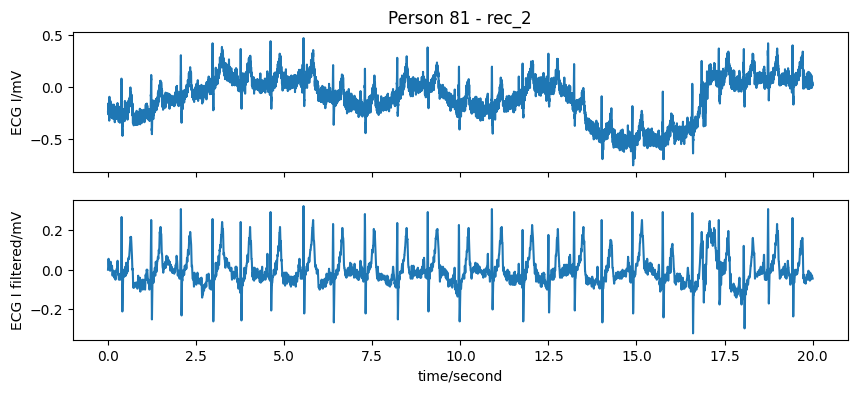

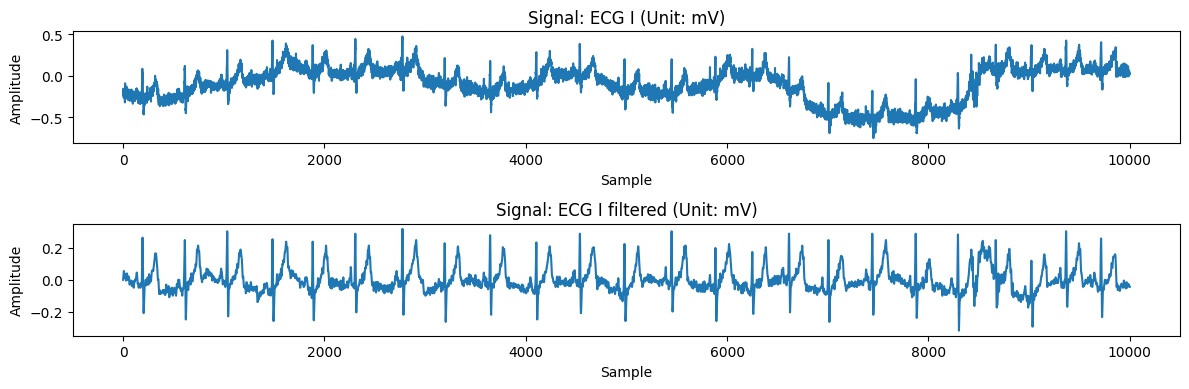


Loading and plotting record: rec_18 from Person_1


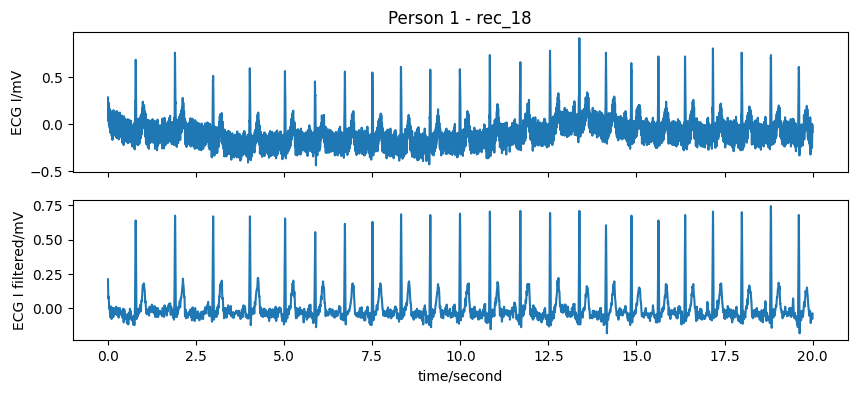

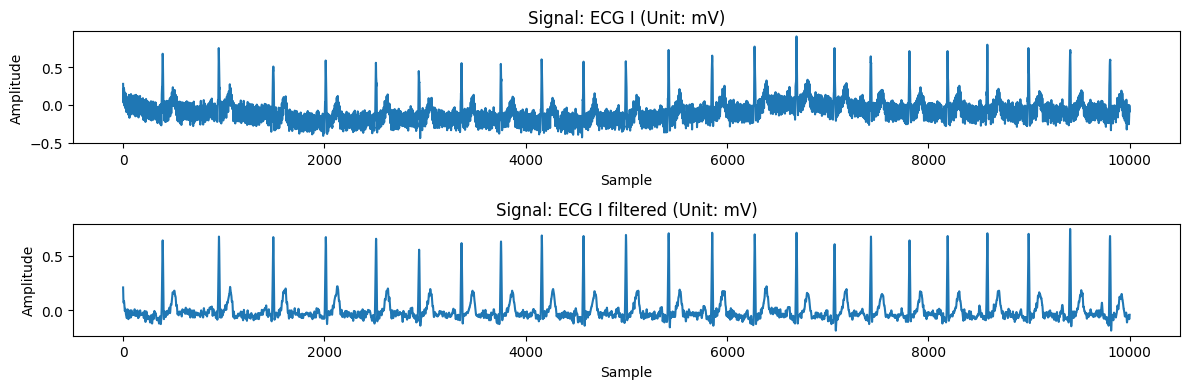


Loading and plotting record: rec_1 from Person_9


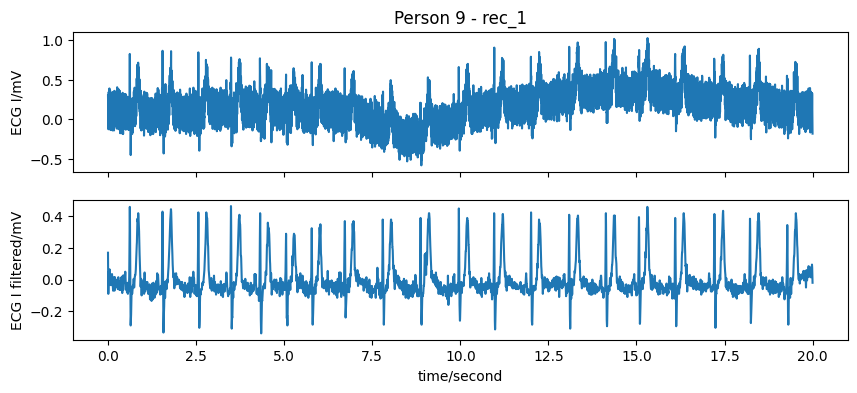

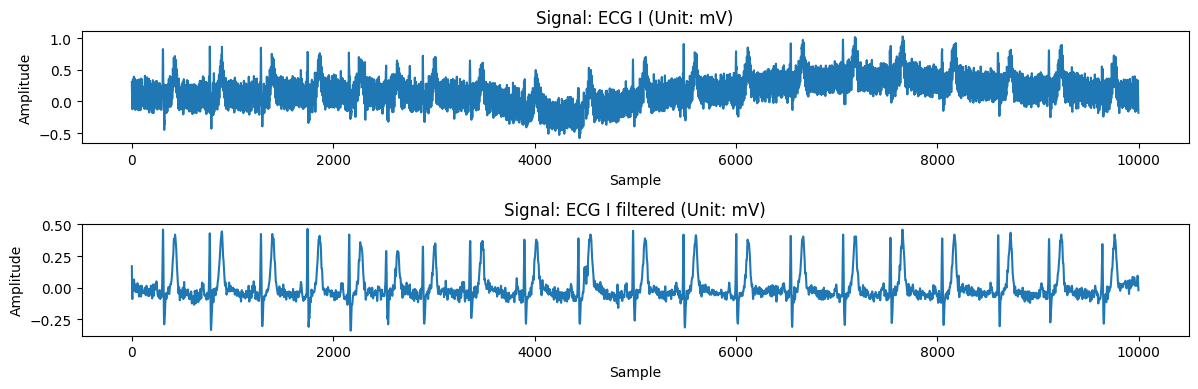

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select a few random records to visualize
sample_records_df = df_records.sample(n=3, random_state=42)

for index, row in sample_records_df.iterrows():
    record_path = row['path']
    person_id = row['person_id']
    record_name = row['record_name']

    print(f"\nLoading and plotting record: {record_name} from Person_{person_id}")
    try:
        record = wfdb.rdrecord(record_path)
        wfdb.plot_wfdb(record=record, title=f'Person {person_id} - {record_name}', figsize=(10, 4))
        plt.show()

        # Also plot individual signals for more detail
        signals = record.p_signal
        if signals is not None:
            num_signals = record.n_sig
            fig, axes = plt.subplots(num_signals, 1, figsize=(12, 2 * num_signals))
            if num_signals == 1:
                axes = [axes] # Make it iterable for consistency

            for i in range(num_signals):
                axes[i].plot(signals[:, i])
                axes[i].set_title(f'Signal: {record.sig_name[i]} (Unit: {record.units[i]})')
                axes[i].set_xlabel('Sample')
                axes[i].set_ylabel('Amplitude')
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"Error loading or plotting record {record_name} for Person_{person_id}: {e}")


## Step 3.0: ECG Data Preprocessing and Filtering


Processing and filtering record: rec_1 from Person_1


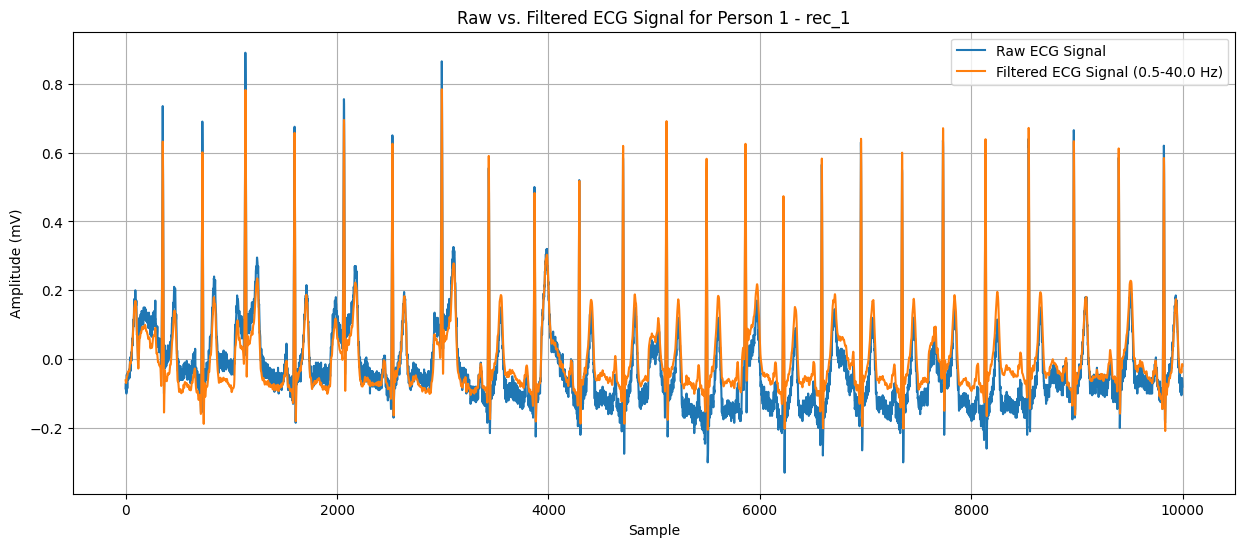

In [ ]:
from scipy.signal import butter, filtfilt
import numpy as np
import matplotlib.pyplot as plt

def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

# Define filtering parameters (common for ECG)
LOWCUT = 0.5  # Hz
HIGHCUT = 40.0 # Hz (to remove muscle noise and powerline interference)

# Process a sample record to demonstrate filtering
# Using the first record from df_records for consistency
sample_record_info = df_records.iloc[0]
sample_record_path = sample_record_info['path']
sampling_frequency = sample_record_info['sampling_frequency']
person_id = sample_record_info['person_id']
record_name = sample_record_info['record_name']

print(f"\nProcessing and filtering record: {record_name} from Person_{person_id}")

try:
    record = wfdb.rdrecord(sample_record_path)
    signals = record.p_signal

    # Assuming we are interested in the first ECG signal (ECG I)
    if signals is not None and signals.shape[1] >= 1:
        raw_ecg_signal = signals[:, 0] # Take the first signal, typically ECG I

        # Apply bandpass filter
        filtered_ecg_signal = butter_bandpass_filter(raw_ecg_signal, LOWCUT, HIGHCUT, sampling_frequency)

        # Plotting the raw vs. filtered signal
        plt.figure(figsize=(15, 6))
        plt.plot(raw_ecg_signal, label='Raw ECG Signal')
        plt.plot(filtered_ecg_signal, label=f'Filtered ECG Signal ({LOWCUT}-{HIGHCUT} Hz)')
        plt.title(f'Raw vs. Filtered ECG Signal for Person {person_id} - {record_name}')
        plt.xlabel('Sample')
        plt.ylabel('Amplitude (mV)')
        plt.legend()
        plt.grid(True)
        plt.show()

    else:
        print(f"No signals found or insufficient signals in record {record_name}")

except Exception as e:
    print(f"Error during filtering for record {record_name}: {e}")


## Step 3.1: QRS Detection, R-peak Segmentation and Normalization

Starting QRS detection, segmentation, and normalization for all records...
Learning initial signal parameters...
Failed to find 8 beats during learning.
Initializing using default parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Failed to find 8 beats during learning.
Initializing using default parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Failed to find 8 beats during learning.
Initializing using default parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Failed to find 8 beats during learning.
Initializing using default parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Failed to find 8 beats during learning.
Initializing using default parameters
Running QRS detection...
QRS detection complete.
Learning initial signal parameters...
Failed to find 8 beats during learning.
Initializing using def

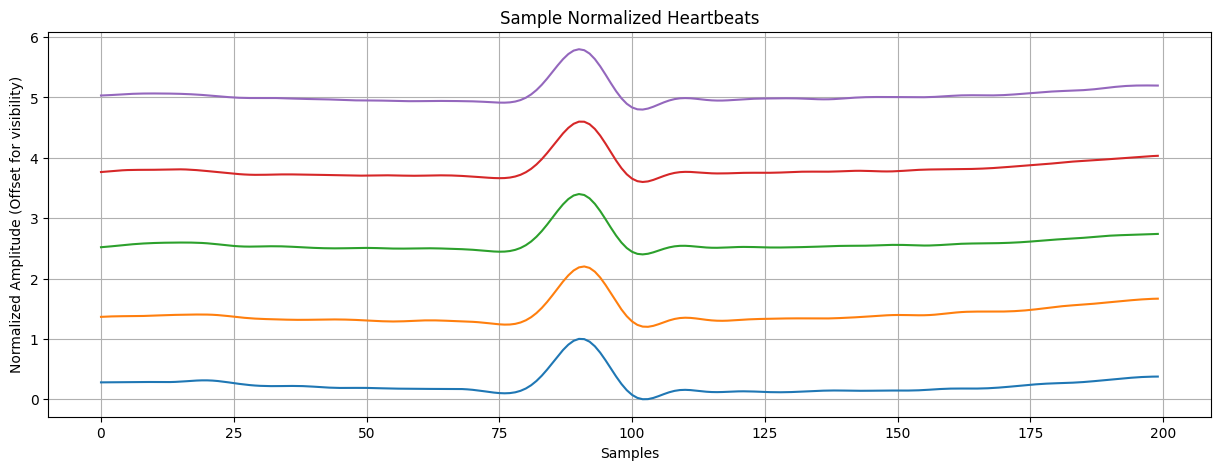

In [ ]:
import wfdb.processing as wp
import numpy as np
import matplotlib.pyplot as plt

def detect_r_peaks(signal, fs):
    # Use Pan-Tompkins algorithm for QRS detection
    # The function returns the sample indices of the R-peaks
    qrs_inds = wp.xqrs_detect(sig=signal, fs=fs)
    return qrs_inds

def segment_heartbeats(signal, r_peaks, fs, pre_R_samples=90, post_R_samples=110):
    heartbeats = []
    for r_peak in r_peaks:
        start_index = r_peak - pre_R_samples
        end_index = r_peak + post_R_samples

        # Ensure the segment is within the signal bounds
        if start_index >= 0 and end_index <= len(signal):
            heartbeat = signal[start_index:end_index]
            heartbeats.append(heartbeat)
    return np.array(heartbeats)

def normalize_heartbeats(heartbeats):
    normalized_beats = []
    for beat in heartbeats:
        # Min-Max Normalization to [0, 1]
        min_val = np.min(beat)
        max_val = np.max(beat)
        if (max_val - min_val) != 0:
            normalized_beat = (beat - min_val) / (max_val - min_val)
        else:
            normalized_beat = np.zeros_like(beat) # Handle flat signals
        normalized_beats.append(normalized_beat)
    return np.array(normalized_beats)

# Initialize lists to store all processed heartbeats and their corresponding person IDs
all_processed_heartbeats = []
all_heartbeat_labels = [] # To store person_id for each heartbeat

print("Starting QRS detection, segmentation, and normalization for all records...")

for index, row in df_records.iterrows():
    record_path = row['path']
    person_id = row['person_id']
    sampling_frequency = row['sampling_frequency']

    try:
        record = wfdb.rdrecord(record_path)
        # Using the first signal (ECG I) which was filtered in the previous step
        raw_ecg_signal = record.p_signal[:, 0]

        # Apply filtering (re-applying or using previously filtered signal if available)
        # For now, let's assume we re-filter. In a real pipeline, ensure consistency.
        filtered_ecg_signal = butter_bandpass_filter(raw_ecg_signal, LOWCUT, HIGHCUT, sampling_frequency)

        # QRS Detection
        r_peaks = detect_r_peaks(filtered_ecg_signal, sampling_frequency)

        # Heartbeat Segmentation
        # Adjust pre_R_samples and post_R_samples based on desired heartbeat length
        # 200 samples at 500 Hz = 0.4 seconds (90 pre, 110 post = 200 total)
        heartbeats = segment_heartbeats(filtered_ecg_signal, r_peaks, sampling_frequency, pre_R_samples=90, post_R_samples=110)

        # Normalization
        normalized_heartbeats = normalize_heartbeats(heartbeats)

        if len(normalized_heartbeats) > 0:
            all_processed_heartbeats.extend(normalized_heartbeats)
            all_heartbeat_labels.extend([person_id] * len(normalized_heartbeats))
            # print(f"Processed Person_{person_id}, Record {row['record_name']}: {len(normalized_heartbeats)} heartbeats.")

    except Exception as e:
        print(f"Error processing record {row['record_name']} for Person_{person_id}: {e}")

# Convert to numpy arrays
all_processed_heartbeats = np.array(all_processed_heartbeats)
all_heartbeat_labels = np.array(all_heartbeat_labels)

print(f"\nTotal processed heartbeats: {len(all_processed_heartbeats)}")
print(f"Shape of all processed heartbeats: {all_processed_heartbeats.shape}")

# Visualize a few normalized heartbeats
plt.figure(figsize=(15, 5))
for i in range(min(5, len(all_processed_heartbeats))):
    plt.plot(all_processed_heartbeats[i] + i * 1.2) # Offset for visualization
plt.title('Sample Normalized Heartbeats')
plt.xlabel('Samples')
plt.ylabel('Normalized Amplitude (Offset for visibility)')
plt.grid(True)
plt.show()


## Step 3.2: Heartbeat Segmentation using Sliding Window Approach to Prepare Data Stream

In [ ]:
def segment_ecg_sliding_window(signal, fs, window_sec=2.0, overlap_sec=1.0):
    samples_per_window = int(window_sec * fs)
    samples_per_overlap = int(overlap_sec * fs)
    step_size = samples_per_window - samples_per_overlap

    segments = []
    for i in range(0, len(signal) - samples_per_window + 1, step_size):
        segment = signal[i : i + samples_per_window]
        segments.append(segment)
    return np.array(segments)

In [ ]:
# Define window and overlap sizes for continuous data stream (e.g., 2 seconds window, 1 second overlap)
WINDOW_SEC = 2.0
OVERLAP_SEC = 1.0

all_stream_segments = []
all_stream_labels = []

print(f"Starting sliding window segmentation (Window: {WINDOW_SEC}s, Overlap: {OVERLAP_SEC}s) for all records...")

for index, row in df_records.iterrows():
    record_path = row['path']
    person_id = row['person_id']
    sampling_frequency = row['sampling_frequency']

    try:
        record = wfdb.rdrecord(record_path)
        raw_ecg_signal = record.p_signal[:, 0]  # First signal (ECG I)

        # Apply bandpass filter
        filtered_ecg_signal = butter_bandpass_filter(raw_ecg_signal, LOWCUT, HIGHCUT, sampling_frequency)

        # Segment using sliding window
        segments = segment_ecg_sliding_window(filtered_ecg_signal, sampling_frequency, WINDOW_SEC, OVERLAP_SEC)

        # Normalize each segment
        normalized_segments = normalize_heartbeats(segments) # Using the same normalization function as for heartbeats

        if len(normalized_segments) > 0:
            all_stream_segments.extend(normalized_segments)
            all_stream_labels.extend([person_id] * len(normalized_segments))

    except Exception as e:
        print(f"Error processing record {row['record_name']} for Person_{person_id} with sliding window: {e}")

all_stream_segments = np.array(all_stream_segments)
all_stream_labels = np.array(all_stream_labels)

print(f"\nTotal processed segments: {len(all_stream_segments)}")
print(f"Shape of all processed segments: {all_stream_segments.shape}")

Starting sliding window segmentation (Window: 2.0s, Overlap: 1.0s) for all records...

Total processed segments: 5890
Shape of all processed segments: (5890, 1000)


### Visualize Sample Sliding Window Segments

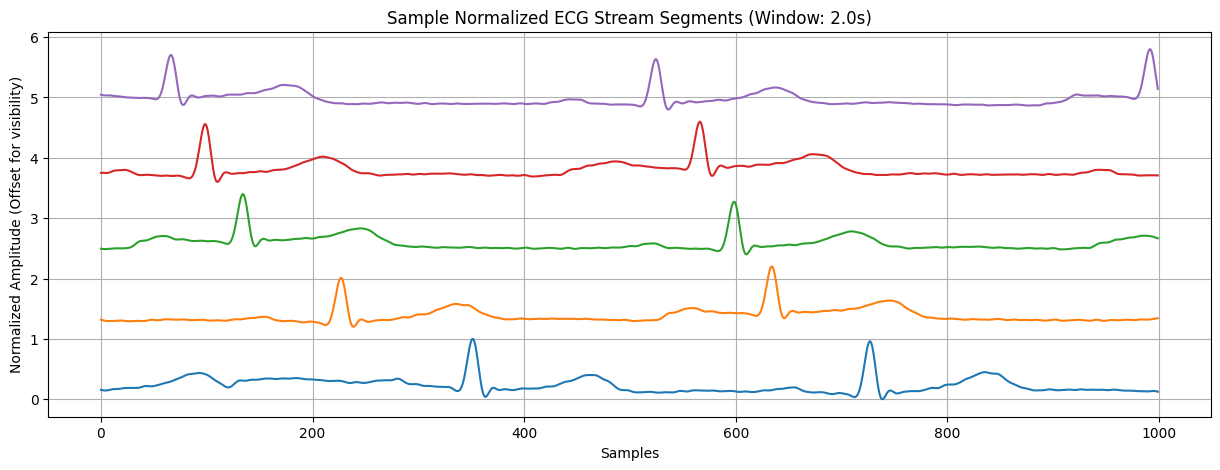

In [ ]:
plt.figure(figsize=(15, 5))
for i in range(min(5, len(all_stream_segments))):
    plt.plot(all_stream_segments[i] + i * 1.2) # Offset for visualization
plt.title(f'Sample Normalized ECG Stream Segments (Window: {WINDOW_SEC}s)')
plt.xlabel('Samples')
plt.ylabel('Normalized Amplitude (Offset for visibility)')
plt.grid(True)
plt.show()

## Step 3.3: Data Splitting (Training and Testing Sets)

In [ ]:
from sklearn.model_selection import train_test_split

# Assuming all_stream_segments and all_stream_labels are ready from the previous step
# X will be the segments, y will be the person_ids
X = all_stream_segments
y = all_stream_labels

# Split data into training and testing sets
# stratify=y ensures that the proportion of target variable (person_id) is the same in both train and test sets
# random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

# Check the distribution of classes in train and test sets to verify stratification
print("\nClass distribution in y_train (first 5):")
print(pd.Series(y_train).value_counts(normalize=True).head())
print("\nClass distribution in y_test (first 5):")
print(pd.Series(y_test).value_counts(normalize=True).head())

Shape of X_train: (4712, 1000)
Shape of y_train: (4712,)
Shape of X_test: (1178, 1000)
Shape of y_test: (1178,)

Class distribution in y_train (first 5):
2     0.070883
1     0.064516
52    0.035441
72    0.025891
9     0.022496
Name: proportion, dtype: float64

Class distribution in y_test (first 5):
2     0.071307
1     0.064516
52    0.035654
72    0.025467
9     0.022920
Name: proportion, dtype: float64


## Step 3.4: Prepare Data for 1D MobileNet and Define Model Architecture

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Assuming all_stream_segments and all_stream_labels are available from Step 3.2
# Reshape X for 1D CNN: (num_samples, timesteps, features)
# Our segments are currently (num_segments, 1000), so we add a feature dimension of 1.
X = all_stream_segments.reshape(all_stream_segments.shape[0], all_stream_segments.shape[1], 1)

# Encode labels (person_id) to numerical format, then one-hot encode them
label_encoder = LabelEncoder()
integer_encoded_labels = label_encoder.fit_transform(all_stream_labels)
y_encoded = to_categorical(integer_encoded_labels)

num_classes = y_encoded.shape[1] # Number of unique persons
input_shape = X.shape[1:] # (1000, 1)

print(f"Reshaped X_data shape for 1D CNN: {X.shape}")
print(f"One-hot encoded y_data shape: {y_encoded.shape}")
print(f"Number of classes (persons): {num_classes}")

Reshaped X_data shape for 1D CNN: (5890, 1000, 1)
One-hot encoded y_data shape: (5890, 90)
Number of classes (persons): 90


In [ ]:
from sklearn.model_selection import train_test_split

# Split the already processed X and y_encoded into training and testing sets
# This ensures X_train_processed, X_test_processed are (num_samples, 1000, 1)
# and y_train_encoded_processed, y_test_encoded_processed are (num_samples, num_classes)
X_train_processed, X_test_processed, y_train_encoded_processed, y_test_encoded_processed = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=integer_encoded_labels
)

print(f"Shape of X_train_processed: {X_train_processed.shape}")
print(f"Shape of y_train_encoded_processed: {y_train_encoded_processed.shape}")
print(f"Shape of X_test_processed: {X_test_processed.shape}")
print(f"Shape of y_test_encoded_processed: {y_test_encoded_processed.shape}")

### 1D MobileNet Architecture

We'll adapt the MobileNet concept of depthwise separable convolutions to a 1D input. This helps in reducing parameters and computational cost while maintaining performance. The model will classify ECG segments into one of the `num_classes` (persons).

In [ ]:
def depthwise_separable_conv1d(x, filters, kernel_size, strides=1, block_id=1):
    # Depthwise Convolution
    x = layers.DepthwiseConv1D(kernel_size=kernel_size, strides=strides, padding='same',
                               activation='relu', use_bias=False,
                               name=f'conv_dw_d{block_id}')(x)
    x = layers.BatchNormalization(name=f'conv_dw_bn{block_id}')(x)

    # Pointwise Convolution
    x = layers.Conv1D(filters, kernel_size=1, strides=1, padding='same',
                      activation='relu', use_bias=False,
                      name=f'conv_pw_c{block_id}')(x)
    x = layers.BatchNormalization(name=f'conv_pw_bn{block_id}')(x)
    return x

def create_mobilenet_1d(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # Initial standard convolution
    x = layers.Conv1D(32, kernel_size=7, strides=2, padding='same', use_bias=False, name='conv1d_1')(inputs)
    x = layers.BatchNormalization(name='bn_conv1d_1')(x)
    x = layers.ReLU(name='relu_conv1d_1')(x)

    # MobileNet blocks
    x = depthwise_separable_conv1d(x, 64, kernel_size=3, strides=1, block_id=1)
    x = depthwise_separable_conv1d(x, 128, kernel_size=3, strides=2, block_id=2)
    x = depthwise_separable_conv1d(x, 128, kernel_size=3, strides=1, block_id=3)
    x = depthwise_separable_conv1d(x, 256, kernel_size=3, strides=2, block_id=4)
    x = depthwise_separable_conv1d(x, 256, kernel_size=3, strides=1, block_id=5)
    x = depthwise_separable_conv1d(x, 512, kernel_size=3, strides=2, block_id=6)
    for i in range(5):
        x = depthwise_separable_conv1d(x, 512, kernel_size=3, strides=1, block_id=7+i)

    x = depthwise_separable_conv1d(x, 1024, kernel_size=3, strides=2, block_id=12)
    x = depthwise_separable_conv1d(x, 1024, kernel_size=3, strides=1, block_id=13)

    # Global Average Pooling
    x = layers.GlobalAveragePooling1D(name='global_average_pooling')(x)

    # Output layer
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = Model(inputs, outputs, name='mobilenet_1d')
    return model

# Create the model
mobilenet_model = create_mobilenet_1d(input_shape, num_classes)

# Display model summary
mobilenet_model.summary()

Model: "mobilenet_1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 500, 32)        │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv1d_1                     │ (None, 500, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_conv1d_1 (ReLU)            │ (None, 500, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_d1 (DepthwiseConv1D)    │ (None, 500, 32)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_bn1                     │ (None, 500, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_c1 (Conv1D)             │ (None, 500, 64)        │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_bn1                     │ (None, 500, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_d2 (DepthwiseConv1D)    │ (None, 250, 64)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_bn2                     │ (None, 250, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_c2 (Conv1D)             │ (None, 250, 128)       │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_bn2                     │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_d3 (DepthwiseConv1D)    │ (None, 250, 128)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_bn3                     │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_c3 (Conv1D)             │ (None, 250, 128)       │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_bn3                     │ (None, 250, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_d4 (DepthwiseConv1D)    │ (None, 125, 128)       │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_bn4                     │ (None, 125, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_c4 (Conv1D)             │ (None, 125, 256)       │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_bn4                     │ (None, 125, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,290,714 (12.55 MB)

 Trainable params: 3,268,826 (12.47 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [ ]:
# Compile the model
mobilenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## Step 3.5: Online Continual Learning Setup (Replay Buffer)

In [ ]:
import random
from collections import deque

class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = deque(maxlen=capacity)

    def add(self, state, label):
        self.buffer.append((state, label))

    def sample(self, batch_size):
        if len(self.buffer) < batch_size:
            return [], [] # Not enough samples to form a batch
        samples = random.sample(self.buffer, batch_size)
        states, labels = zip(*samples)
        return np.array(states), np.array(labels)

    def __len__(self):
        return len(self.buffer)

# Define parameters for the online learning simulation
STREAM_CHUNK_SIZE = 100 # Process 100 segments at a time
REPLAY_BUFFER_CAPACITY = 500 # Capacity of the replay buffer
REPLAY_BATCH_SIZE = 32 # Number of samples to draw from replay buffer
ONLINE_EPOCHS_PER_CHUNK = 1 # How many epochs to train on the current chunk + replay

# Initialize replay buffer
replay_buffer = ReplayBuffer(REPLAY_BUFFER_CAPACITY)

print(f"Starting online continual learning simulation with stream chunks of size {STREAM_CHUNK_SIZE}...")
print(f"Replay buffer capacity: {REPLAY_BUFFER_CAPACITY}, Replay batch size: {REPLAY_BATCH_SIZE}")

# Simulate data stream and online learning
num_total_segments = X.shape[0]

# Store metrics for visualization later
online_loss_history = []
online_accuracy_history = []

for i in range(0, num_total_segments, STREAM_CHUNK_SIZE):
    current_chunk_X = X[i:i + STREAM_CHUNK_SIZE]
    current_chunk_y = y_encoded[i:i + STREAM_CHUNK_SIZE]

    if len(current_chunk_X) == 0: # Handle cases where last chunk might be empty
        continue

    print(f"\nProcessing stream chunk {int(i/STREAM_CHUNK_SIZE) + 1}/{int(num_total_segments/STREAM_CHUNK_SIZE) + 1} (samples {i} to {i + len(current_chunk_X) - 1})")

    # Add current chunk to replay buffer
    for j in range(len(current_chunk_X)):
        replay_buffer.add(current_chunk_X[j], current_chunk_y[j])

    # Prepare training data: current chunk + samples from replay buffer
    train_X = current_chunk_X
    train_y = current_chunk_y

    if len(replay_buffer) >= REPLAY_BATCH_SIZE:
        replay_X, replay_y = replay_buffer.sample(REPLAY_BATCH_SIZE)
        train_X = np.concatenate((train_X, replay_X))
        train_y = np.concatenate((train_y, replay_y))

    if len(train_X) > 0:
        # Train the model on the combined data
        history = mobilenet_model.fit(train_X, train_y, epochs=ONLINE_EPOCHS_PER_CHUNK, verbose=0) # Set verbose to 1 for more detailed output
        online_loss_history.append(history.history['loss'][0])
        online_accuracy_history.append(history.history['accuracy'][0])
        print(f"  -> Training loss: {online_loss_history[-1]:.4f}, Training accuracy: {online_accuracy_history[-1]:.4f}")
    else:
        print("  -> No data to train on in this chunk.")

print("\nOnline continual learning simulation finished.")

Starting online continual learning simulation with stream chunks of size 100...
Replay buffer capacity: 500, Replay batch size: 32

Processing stream chunk 1/59 (samples 0 to 99)
  -> Training loss: 4.4655, Training accuracy: 0.0227

Processing stream chunk 2/59 (samples 100 to 199)
  -> Training loss: 4.2253, Training accuracy: 0.2121

Processing stream chunk 3/59 (samples 200 to 299)
  -> Training loss: 3.9096, Training accuracy: 0.5758

Processing stream chunk 4/59 (samples 300 to 399)
  -> Training loss: 3.3276, Training accuracy: 0.8258

Processing stream chunk 5/59 (samples 400 to 499)
  -> Training loss: 2.4900, Training accuracy: 0.7500

Processing stream chunk 6/59 (samples 500 to 599)
  -> Training loss: 1.5971, Training accuracy: 0.8712

Processing stream chunk 7/59 (samples 600 to 699)
  -> Training loss: 1.5299, Training accuracy: 0.8712

Processing stream chunk 8/59 (samples 700 to 799)
  -> Training loss: 2.1385, Training accuracy: 0.8258

Processing stream chunk 9/59 (s

### Placeholder for ADWIN (Adaptive Windowing) for Drift Detection

ADWIN would typically be integrated into this loop to monitor model performance or data distribution. If ADWIN detects a significant change (drift), it would signal the model to adapt more aggressively, perhaps by increasing the training epochs on new data or adjusting learning rates. This will be an advanced topic to explore if needed.

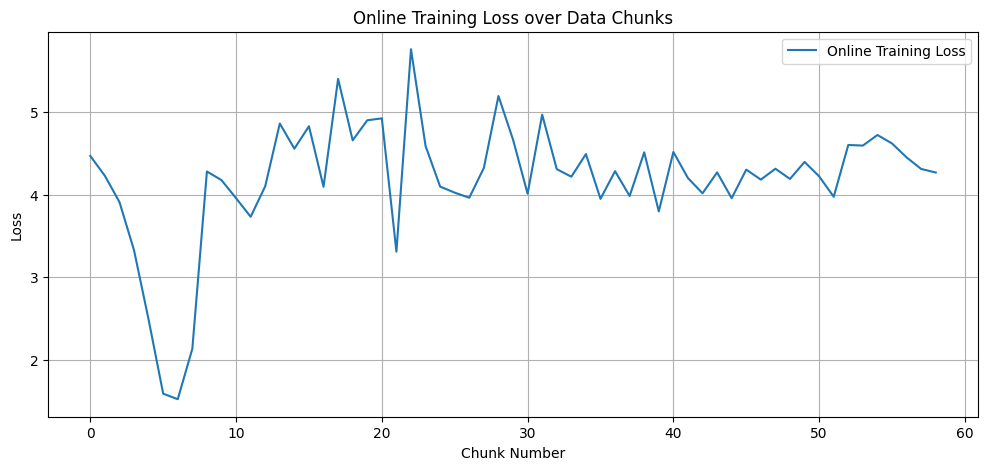

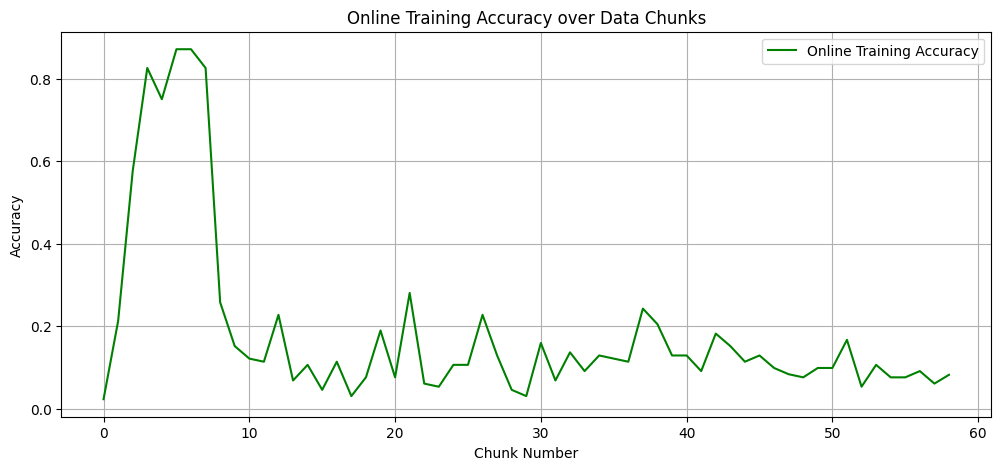

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(online_loss_history, label='Online Training Loss')
plt.title('Online Training Loss over Data Chunks')
plt.xlabel('Chunk Number')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(online_accuracy_history, label='Online Training Accuracy', color='green')
plt.title('Online Training Accuracy over Data Chunks')
plt.xlabel('Chunk Number')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Step 3.6: Integrate ADWIN for Concept Drift Detection

In [ ]:
# A simplified ADWIN implementation (for demonstration)
# In a real scenario, you might use a dedicated library or a more robust implementation

class Adwin:
    def __init__(self, delta=0.002, min_window_length=10):
        self.delta = delta
        self.min_window_length = min_window_length
        self.window = deque()
        self.sum_val = 0.0
        self.variance = 0.0

    def add_element(self, value):
        self.window.append(value)
        self.sum_val += value
        # Update variance (simple approximation, true online variance update is more complex)
        # For simplicity, we'll recompute/approximate on the fly for demonstration

        if len(self.window) > self.min_window_length:
            return self._detect_drift()
        return False

    def _detect_drift(self):
        # Simplified drift detection logic based on mean change
        # This is a very basic heuristic, not the full ADWIN algorithm.
        # The full ADWIN algorithm involves splitting the window dynamically and comparing means.
        # For illustration, we'll just check if the current mean deviates significantly from an older mean.

        if len(self.window) < self.min_window_length * 2: # Need enough data to compare two sub-windows
            return False

        n = len(self.window)
        n0 = n // 2 # Split into two halves for simplicity

        window1 = list(self.window)[:n0]
        window2 = list(self.window)[n0:]

        mean1 = sum(window1) / n0
        mean2 = sum(window2) / (n - n0)

        # Heuristic: if means differ by more than a threshold, signal drift
        # A more rigorous statistical test (like Hoeffding bounds) would be used in full ADWIN
        epsilon = np.sqrt(2 * self.delta * np.log(1/self.delta) / n)
        if abs(mean1 - mean2) > epsilon * 2: # Multiply epsilon by 2 as a heuristic threshold
            # print(f"Drift detected! Mean1: {mean1:.4f}, Mean2: {mean2:.4f}, Threshold: {epsilon * 2:.4f}")
            return True
        return False

# Re-initialize for a fresh run with ADWIN
replay_buffer = ReplayBuffer(REPLAY_BUFFER_CAPACITY)

# Initialize ADWIN to monitor training loss (or accuracy)
adwin_loss = Adwin(delta=0.01, min_window_length=20) # Monitor loss changes

online_loss_history_adwin = []
online_accuracy_history_adwin = []
drift_detected_chunks = []

print(f"\nStarting online continual learning simulation with ADWIN integration...")
print(f"Monitoring loss for drift with ADWIN (delta={adwin_loss.delta}, min_window_length={adwin_loss.min_window_length})...")

# Re-compile the model to reset optimizer state at the beginning of the ADWIN run
mobilenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

for i in range(0, num_total_segments, STREAM_CHUNK_SIZE):
    current_chunk_X = X[i:i + STREAM_CHUNK_SIZE]
    current_chunk_y = y_encoded[i:i + STREAM_CHUNK_SIZE]

    if len(current_chunk_X) == 0:
        continue

    chunk_num = int(i/STREAM_CHUNK_SIZE) + 1
    print(f"\nProcessing stream chunk {chunk_num}/{int(num_total_segments/STREAM_CHUNK_SIZE) + 1} (samples {i} to {i + len(current_chunk_X) - 1})")

    # Add current chunk to replay buffer
    for j in range(len(current_chunk_X)):
        replay_buffer.add(current_chunk_X[j], current_chunk_y[j])

    # Prepare training data: current chunk + samples from replay buffer
    train_X = current_chunk_X
    train_y = current_chunk_y

    if len(replay_buffer) >= REPLAY_BATCH_SIZE:
        replay_X, replay_y = replay_buffer.sample(REPLAY_BATCH_SIZE)
        train_X = np.concatenate((train_X, replay_X))
        train_y = np.concatenate((train_y, replay_y))

    if len(train_X) > 0:
        # Train the model
        history = mobilenet_model.fit(train_X, train_y, epochs=ONLINE_EPOCHS_PER_CHUNK, verbose=0)
        current_loss = history.history['loss'][0]
        current_accuracy = history.history['accuracy'][0]

        online_loss_history_adwin.append(current_loss)
        online_accuracy_history_adwin.append(current_accuracy)

        # ADWIN drift detection on the current training loss
        drift_detected = adwin_loss.add_element(current_loss)

        if drift_detected:
            drift_detected_chunks.append(chunk_num)
            print(f"  --> ADWIN Detected Concept Drift in Chunk {chunk_num}! Recompiling model to reset optimizer state for adaptation.")
            # Adaptive measure: Recompile the model to reset optimizer state (e.g., Adam's momentum terms)
            mobilenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

        print(f"  -> Training loss: {current_loss:.4f}, Training accuracy: {current_accuracy:.4f}")
    else:
        print("  -> No data to train on in this chunk.")

print("\nOnline continual learning simulation with ADWIN finished.")


Starting online continual learning simulation with ADWIN integration...
Monitoring loss for drift with ADWIN (delta=0.01, min_window_length=20)...

Processing stream chunk 1/59 (samples 0 to 99)
  -> Training loss: 4.9194, Training accuracy: 0.0000

Processing stream chunk 2/59 (samples 100 to 199)
  -> Training loss: 4.4024, Training accuracy: 0.0000

Processing stream chunk 3/59 (samples 200 to 299)
  -> Training loss: 3.9600, Training accuracy: 0.0227

Processing stream chunk 4/59 (samples 300 to 399)
  -> Training loss: 3.5377, Training accuracy: 0.7348

Processing stream chunk 5/59 (samples 400 to 499)
  -> Training loss: 3.4478, Training accuracy: 0.4848

Processing stream chunk 6/59 (samples 500 to 599)
  -> Training loss: 1.6008, Training accuracy: 0.8409

Processing stream chunk 7/59 (samples 600 to 699)
  -> Training loss: 1.7944, Training accuracy: 0.9091

Processing stream chunk 8/59 (samples 700 to 799)
  -> Training loss: 0.8696, Training accuracy: 0.9318

Processing str

### Visualize Online Learning Metrics with ADWIN Drift Points

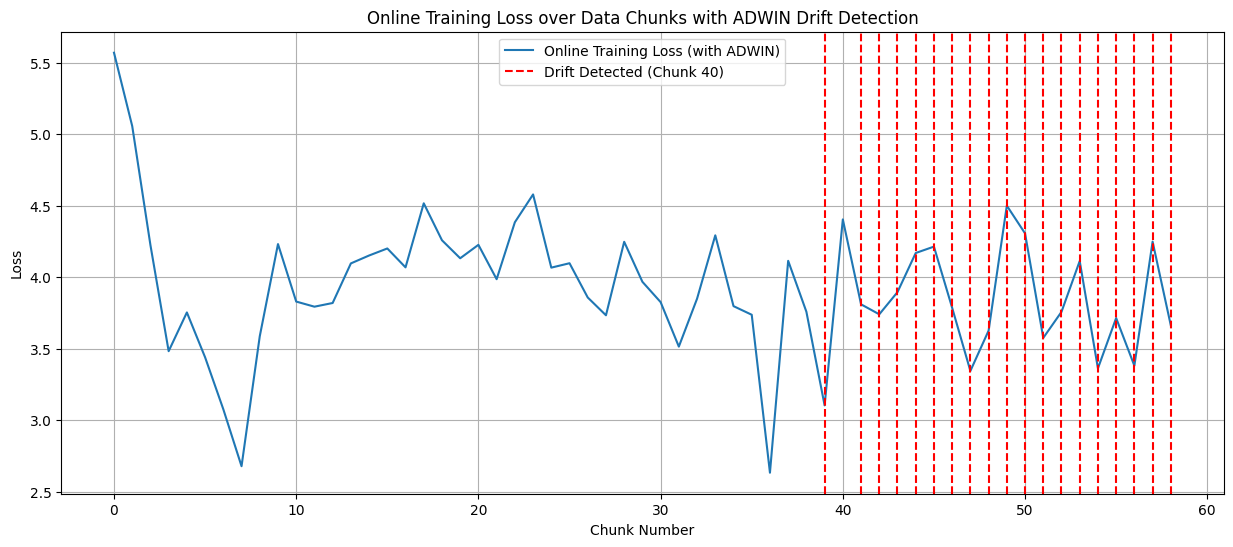

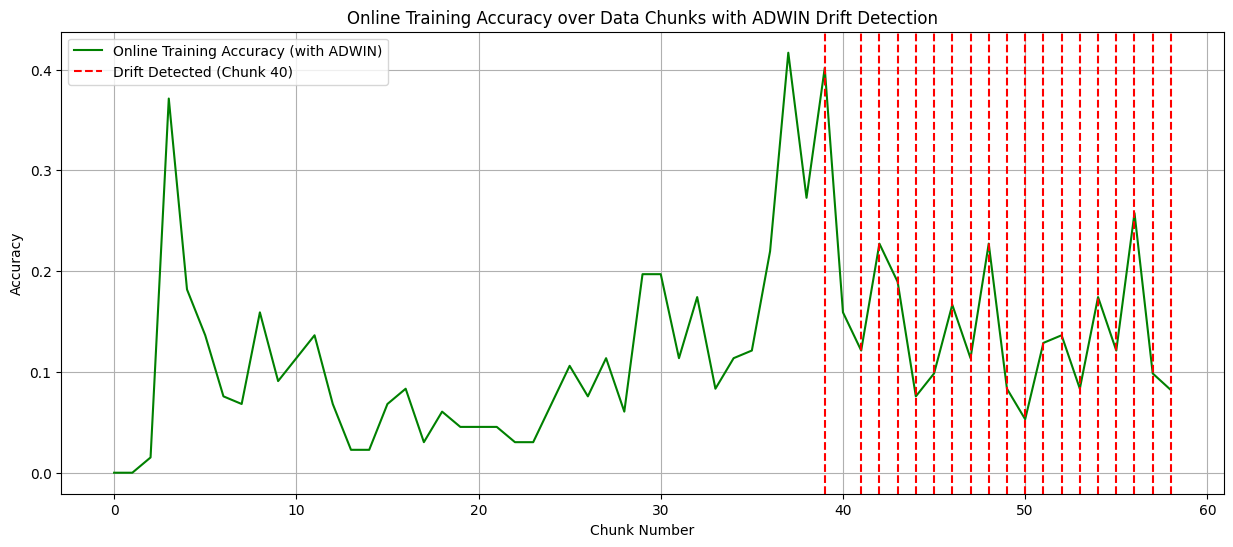

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(online_loss_history_adwin, label='Online Training Loss (with ADWIN)')
for drift_chunk in drift_detected_chunks:
    plt.axvline(x=drift_chunk - 1, color='r', linestyle='--', label=f'Drift Detected (Chunk {drift_chunk})' if drift_chunk == drift_detected_chunks[0] else '')
plt.title('Online Training Loss over Data Chunks with ADWIN Drift Detection')
plt.xlabel('Chunk Number')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(online_accuracy_history_adwin, label='Online Training Accuracy (with ADWIN)', color='green')
for drift_chunk in drift_detected_chunks:
    plt.axvline(x=drift_chunk - 1, color='r', linestyle='--', label=f'Drift Detected (Chunk {drift_chunk})' if drift_chunk == drift_detected_chunks[0] else '')
plt.title('Online Training Accuracy over Data Chunks with ADWIN Drift Detection')
plt.xlabel('Chunk Number')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()